<a href="https://colab.research.google.com/github/pauloed94/ia-ciberseguranca/blob/main/aula3_ml_ciberseguranca_cicids2017_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aula 3
## Dados e features em segurança: classificação de ataques e clustering (CIC-IDS2017)

**Dupla:** `Paulo Eduardo`  ·  `André Coelho`

> Rodem as células na ordem.

Nesta aula prática vamos trabalhar com **tráfego de rede real** do CIC-IDS2017 e percorrer, de ponta a ponta:
dados → EDA → preparação → **Random Forest** (supervisionado) → feature importance → **K-Means** (não supervisionado) → comparação.

O foco é **entender os dados e as features de segurança** e ver, na prática, a diferença entre classificar ataques (com rótulos) e descobrir grupos (sem rótulos).

## 1. Introdução

O **CIC-IDS2017** (Canadian Institute for Cybersecurity) contém fluxos de rede capturados numa rede de teste com tráfego benigno e vários ataques (DoS, DDoS, PortScan, força bruta, web attacks, etc.).

- **Cada registro é um fluxo de rede** — uma conexão resumida por dezenas de features (duração, nº de pacotes, bytes por segundo, tamanhos de pacote, flags TCP…), extraídas pelo CICFlowMeter.
- **Classificar como benigno ou ataque** é decidir, a partir dessas features, se aquele fluxo é comportamento normal ou malicioso.
- **Por que ML?** As assinaturas tradicionais só pegam ataques conhecidos. Modelos aprendem padrões nas features e generalizam para variações — úteis quando o volume de tráfego é grande demais para regras manuais.

> Não vamos aprofundar teoria: a ideia é **mexer nos dados** e interpretar o que sai.

# Motivação sobre ML-Based Intrusion Detection

---

* Mesmo com diferentes mecanismos de autenticação, firewall, criptografia e segurança de modo geral sendo aplicados em todas as camadas, ataques ainda são possíveis e acontecem.

* Sistemas de detecção de intrusão são o último recurso de segurança
  * Detectam e reportam a ocorrência de ataques e atividades suspeitas quando outros mecanismos de segurança não conseguem impedi-los
  * Tais como outros mecanismos de segurança, são amplamente utilizados
    * Mas costumam apresentar vários problemas e limitações:
      * Dependência de assinaturas e limitação a ataques conhecidos
      * Necessidade de analisar e rotular grandes quantidades de dados
      * Tempos de detecção longos
      * ...

* O uso de **inteligência artificial** pode ajudar em superar esses problemas e limitações

# Sistemas de Detecção de Intrusão

---

* **Second Line of Defense**
* **Last Security Resource**
* **Monitor Networks and Systems**
* **Detect and Report Suspicious Activities**

---

### **Taxonomy**

| Monitoring Environment | Placement Strategy | Operation Mode | Detection Method |
| :--- | :--- | :--- | :--- |
| • Host-based | • Centralized | • Off-line | • Signature-based |
| • Network-based | • Distributed | • Real-time | • Anomaly-based |
| | | | • Hybrid |

# Sistemas de Detecção de Intrusão

---

* **Baseados em assinaturas**
  * Regras de detecção baseadas em atividades maliciosas
  * Precisa-se entender a atividade maliciosa e como ela impacta determinados atributos

* **Baseados em anomalia**
  * Regras de detecção baseadas em desvios do comportamento benigno
  * Precisa-se estabelecer qual o comportamento benigno de determinado sistema ou rede e medir desvios desse comportamento

---

> ➤ **Essas duas estratégias se complementam, pois uma olha para as atividades maliciosas e a outra para as atividades normais.**

## 2. Bibliotecas e configuração

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, silhouette_score)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

## 3. Carregamento dos dados

## Opção C — CSE-CIC-IDS2018 (apenas um dia — recomendado)
Continuação do 2017, mesmo esquema de ~80 features + `Label`. Baixamos **um** arquivo
limpo (28-02, ~200 MB) direto do AWS S3 público. Aqui o benigno vem como **`Benign`** —
a normalização cuida disso.

In [ ]:
!pip install -q awscli
!aws s3 cp --no-sign-request --region ca-central-1 "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv" wed2018.csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 32.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv to ./wed2018.csv


In [ ]:
# Carrega e concatena todos os CSVs
df = pd.read_csv('wed2018.csv', low_memory=False)
df.columns = df.columns.str.strip()

# 2018 usa 'Benign' (B maiúsculo) -> padroniza para 'BENIGN'
df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:12], '...')
df.head()

Dimensões: (613104, 80)
Rótulos: ['BENIGN' 'Label' 'Infilteration'] ...


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,28/02/2018 08:22:13,94658,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,443,6,28/02/2018 08:22:13,206,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
2,445,6,28/02/2018 08:22:15,165505,3,1,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
3,443,6,28/02/2018 08:22:16,102429,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
4,443,6,28/02/2018 08:22:16,167,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN


Vamos olhar os tipos das variáveis e identificar a coluna alvo (`Label`).

In [ ]:
print('Coluna alvo: Label ->', df['Label'].unique()[:8], '...')
df.info()

Coluna alvo: Label -> ['BENIGN' 'Label' 'Infilteration'] ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613104 entries, 0 to 613103
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Dst Port           613104 non-null  object
 1   Protocol           613104 non-null  object
 2   Timestamp          613104 non-null  object
 3   Flow Duration      613104 non-null  object
 4   Tot Fwd Pkts       613104 non-null  object
 5   Tot Bwd Pkts       613104 non-null  object
 6   TotLen Fwd Pkts    613104 non-null  object
 7   TotLen Bwd Pkts    613104 non-null  object
 8   Fwd Pkt Len Max    613104 non-null  object
 9   Fwd Pkt Len Min    613104 non-null  object
 10  Fwd Pkt Len Mean   613104 non-null  object
 11  Fwd Pkt Len Std    613104 non-null  object
 12  Bwd Pkt Len Max    613104 non-null  object
 13  Bwd Pkt Len Min    613104 non-null  object
 14  Bwd Pkt Len Mean   613104 non-null  object
 15  Bwd Pkt

### Verificando problemas nos dados
O CIC-IDS2017 tem três problemas conhecidos: **registros duplicados**, **valores NaN** e **valores infinitos** (em features como `Flow Bytes/s`, que dividem por tempo e podem estourar).

In [ ]:
print('Duplicatas :', df.duplicated().sum())
print('NaN totais :', int(df.isna().sum().sum()))
inf_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if np.isinf(df[c]).any()]
print('Colunas com valores infinitos:', inf_cols)

Duplicatas : 6121
NaN totais : 4041
Colunas com valores infinitos: []


### Limpeza
Descartamos duplicatas e NaN; para os infinitos, seguimos a abordagem das aulas anteriores — substituir pelo **maior valor finito** da coluna, preservando o registro.

In [ ]:
ini = len(df)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Duplicatas/NaN removidos: {ini - len(df)}  |  restam {len(df)} registros')

for col in df.select_dtypes(include=[np.number]).columns:
    mask_inf = np.isinf(df[col])
    if mask_inf.any():
        df.loc[mask_inf, col] = df.loc[~mask_inf, col].max()
print('Infinitos tratados. Dimensões:', df.shape)

Duplicatas/NaN removidos: 8790  |  restam 604314 registros
Infinitos tratados. Dimensões: (604314, 80)


Padronizamos os rótulos de *web attacks*, que vêm com caracteres estranhos de codificação.

In [ ]:
df['Label'] = (df['Label'].str.replace('Web Attack.*Brute Force', 'Web Attack - Brute Force', regex=True)
                            .str.replace('Web Attack.*XSS', 'Web Attack - XSS', regex=True)
                            .str.replace('Web Attack.*Sql Injection', 'Web Attack - Sql Injection', regex=True))
df['Label'].value_counts()

,count
Label,
BENIGN,535865
Infilteration,68448
Label,1


### Amostra de trabalho
Para o notebook rodar rápido em qualquer máquina, tiramos uma **amostra estratificada** (~200 mil fluxos), preservando a proporção original entre classes. Assim mantemos o desbalanceamento realista, mas com custo baixo.

In [ ]:
N_ALVO = 200_000
if len(df) > N_ALVO:
    frac = N_ALVO / len(df)
    df = (df.groupby('Label', group_keys=False)
            .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))
            .reset_index(drop=True))
print('Amostra de trabalho:', df.shape)

/tmp/ipykernel_1952/1716381155.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))


Amostra de trabalho: (200001, 80)


## 4. EDA simples

Comecemos pelo essencial: **quanto do tráfego é ataque** e **quais ataques** aparecem.

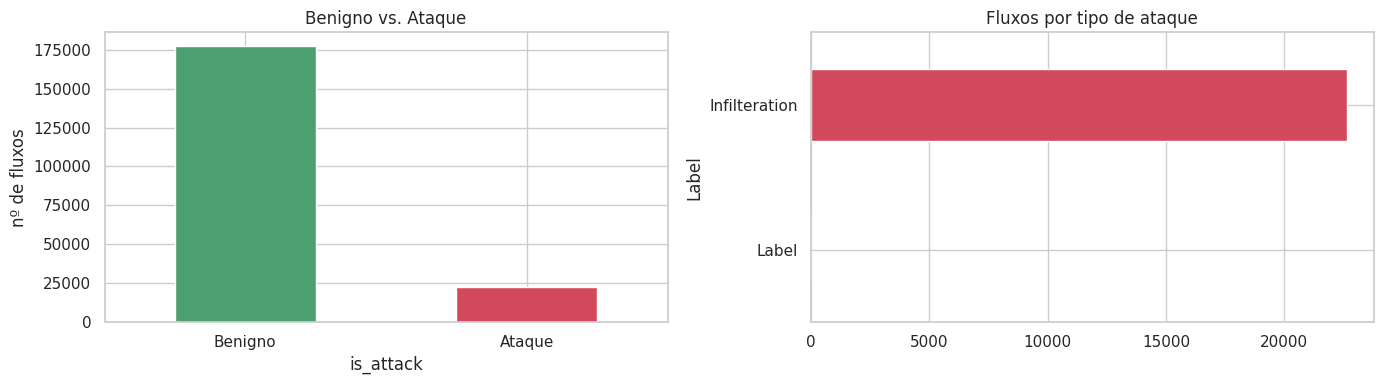

In [ ]:
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['is_attack'].map({0:'Benigno', 1:'Ataque'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#4C9F70', '#D1495B'])
ax[0].set_title('Benigno vs. Ataque'); ax[0].set_ylabel('nº de fluxos')
ax[0].tick_params(axis='x', rotation=0)

ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts()
ataques.plot(kind='barh', ax=ax[1], color='#D1495B')
ax[1].set_title('Fluxos por tipo de ataque'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**O que observar:** o tráfego é **fortemente desbalanceado** — a imensa maioria é benigna, e entre os ataques alguns tipos (DoS Hulk, PortScan, DDoS) dominam enquanto outros têm pouquíssimos exemplos. Isso afeta tanto o treino quanto a escolha de métricas mais adiante.

Vamos olhar a escala de algumas features numéricas típicas de fluxo.

In [ ]:
cols_interesse = [
    'Flow Duration',
    'Flow Byts/s',
    'Tot Fwd Pkts',
    'Pkt Size Avg',
    'SYN Flag Cnt'
]

df[cols_interesse].describe()

,Flow Duration,Flow Byts/s,Tot Fwd Pkts,Pkt Size Avg,SYN Flag Cnt
count,200001,200001,200001,200001,200001
unique,83374,119949,252,15905,3
top,2,0,1,0,0
freq,6649,54019,84488,54019,186874


Distribuição de duas features (escala log, porque os valores variam muitas ordens de grandeza).

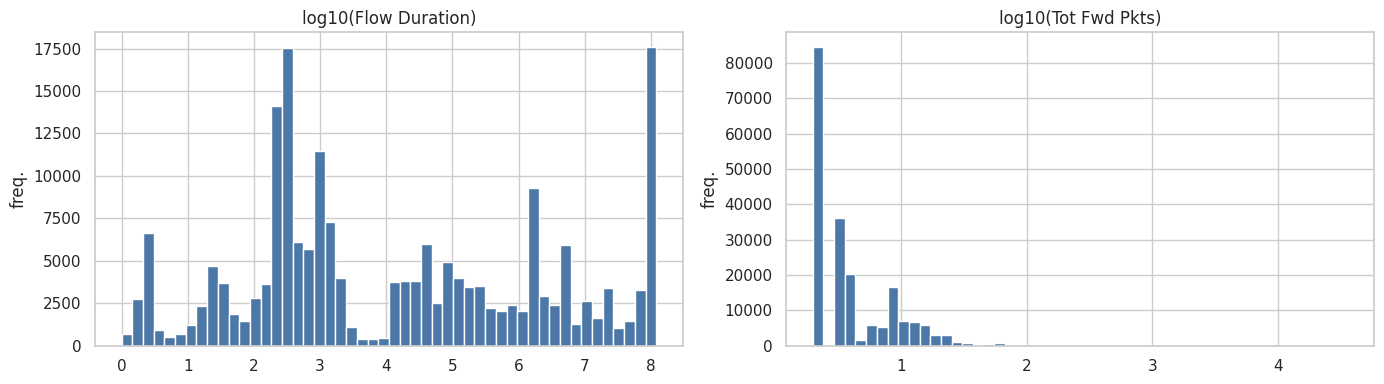

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

for a, col in zip(ax, ['Flow Duration', 'Tot Fwd Pkts']):
    vals = pd.to_numeric(df[col], errors='coerce')
    vals = vals.clip(lower=0).dropna()

    a.hist(np.log10(vals + 1), bins=50, color='#4C78A8')
    a.set_title(f'log10({col})')
    a.set_ylabel('freq.')

plt.tight_layout()
plt.show()

**O que observar:** distribuições muito assimétricas e de cauda longa — comuns em tráfego de rede. É por isso que, para modelos baseados em distância (K-Means), a **padronização** será importante.

Comparando uma feature entre benigno e alguns ataques (boxplot).

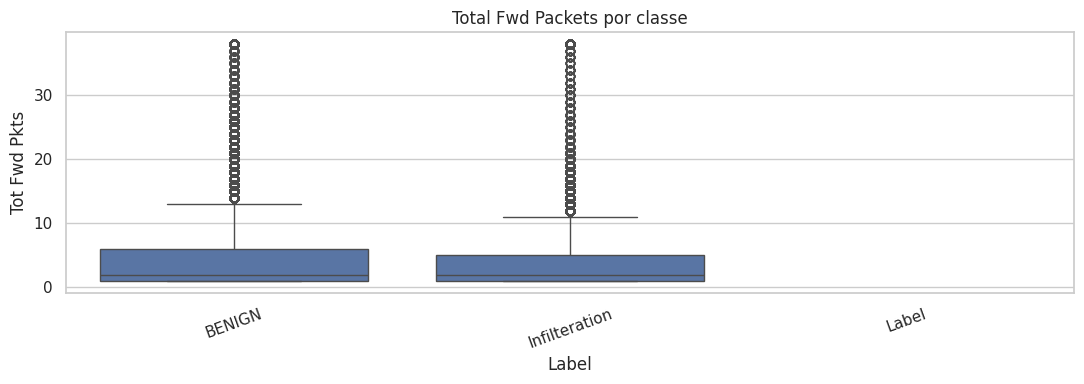

In [ ]:
top_ataques = (
    df[df['Label'] != 'BENIGN']['Label']
    .value_counts()
    .head(4)
    .index
    .tolist()
)

sub = df[df['Label'].isin(['BENIGN'] + top_ataques)].copy()

sub['Tot Fwd Pkts'] = pd.to_numeric(
    sub['Tot Fwd Pkts'],
    errors='coerce'
)

sub['Tot Fwd Pkts'] = sub['Tot Fwd Pkts'].clip(
    upper=sub['Tot Fwd Pkts'].quantile(0.99)
)

plt.figure(figsize=(11, 4))

sns.boxplot(
    data=sub,
    x='Label',
    y='Tot Fwd Pkts',
    order=['BENIGN'] + top_ataques
)

plt.xticks(rotation=20)
plt.title('Total Fwd Packets por classe')
plt.tight_layout()
plt.show()

**O que observar:** algumas classes de ataque têm distribuição de pacotes bem diferente do tráfego benigno — é exatamente esse tipo de separação que o modelo vai explorar.

Correlação entre um subconjunto de features (para não poluir com 78 colunas).

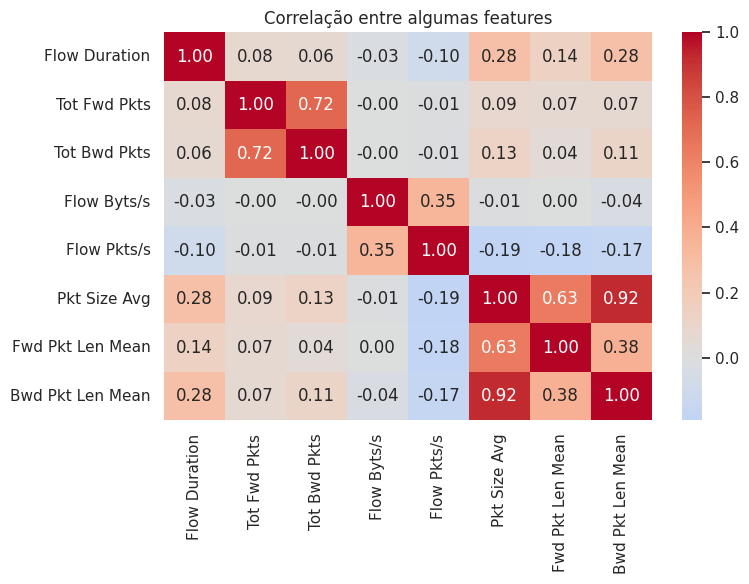

In [ ]:
cols_corr = [
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'Flow Byts/s',
    'Flow Pkts/s',
    'Pkt Size Avg',
    'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean'
]

# garante que só entram colunas existentes
cols_corr = [c for c in cols_corr if c in df.columns]

# converte para numérico
df_corr = df[cols_corr].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlação entre algumas features')
plt.tight_layout()
plt.show()

**O que observar:** pares de features muito correlacionados (ex.: contagens e tamanhos de pacote) carregam informação redundante — algo a considerar ao escolher features.

## 5. Preparação dos dados

- **Alvo:** vamos classificar **Benigno (0) vs. Ataque (1)** — um problema binário, claro para começar.
- **Features:** todas as colunas numéricas de fluxo.
- **Data leakage:** fazemos o `train_test_split` **antes** de qualquer ajuste que dependa dos dados (aqui o Random Forest nem precisa de normalização; a padronização entra só no K-Means, ajustada no conjunto certo).

In [ ]:
y = (df['Label'] != 'BENIGN').astype(int)

X = df.drop(columns=['Label', 'is_attack', 'Timestamp'], errors='ignore').copy()

# converter todas as features possíveis para número
X = X.apply(pd.to_numeric, errors='coerce')

# tratar infinitos
X = X.replace([np.inf, -np.inf], np.nan)

# remover colunas que ficaram completamente vazias após conversão
X = X.dropna(axis=1, how='all')

# preencher valores ausentes restantes pela mediana
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_SEED
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print(
    'Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(
        y_train.mean(),
        y_test.mean()
    )
)

Treino: (140000, 78) | Teste: (60001, 78)
Proporção de ataque — treino: 11.3% | teste: 11.3%


## 6. Modelo supervisionado — Random Forest

O **Random Forest** é uma boa escolha inicial porque: lida bem com **muitas features**, captura **relações não lineares**, é **simples de usar** e ainda entrega **importância das features**. Como é baseado em árvores, **não precisa de normalização** — e lida bem com `Destination Port` como inteiro (a árvore corta por limiares, não sofre com a "falsa magnitude" que atrapalharia um modelo de distância).

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Treino concluído.')

Treino concluído.


### Avaliação
Com dados desbalanceados, **acurácia sozinha engana**. Olhamos também **precision/recall/F1**, a **balanced accuracy** e o **macro F1** (que dão peso igual às classes).

              precision    recall  f1-score   support

     Benigno       0.89      0.92      0.90     53205
      Ataque       0.13      0.09      0.11      6796

    accuracy                           0.83     60001
   macro avg       0.51      0.51      0.51     60001
weighted avg       0.80      0.83      0.81     60001

Balanced accuracy: 0.5058
Macro F1        : 0.5052


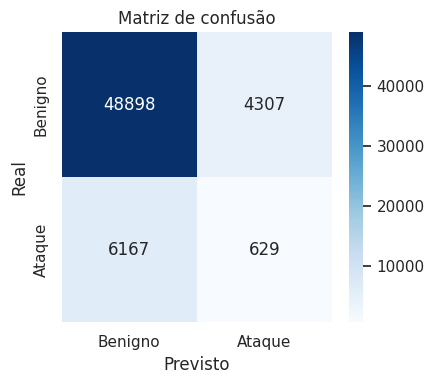

In [ ]:
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Ataque']))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred), 4))
print('Macro F1        :', round(f1_score(y_test, y_pred, average='macro'), 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Ataque'], yticklabels=['Benigno', 'Ataque'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

**O que observar:** onde estão os erros? Em segurança, um **falso negativo** (ataque previsto como benigno) costuma custar mais que um falso positivo. A matriz de confusão mostra qual dos dois o modelo comete mais.

## 7. Feature Importance

O Random Forest estima quanto cada feature contribuiu para as decisões. Vejamos as 15 mais importantes.

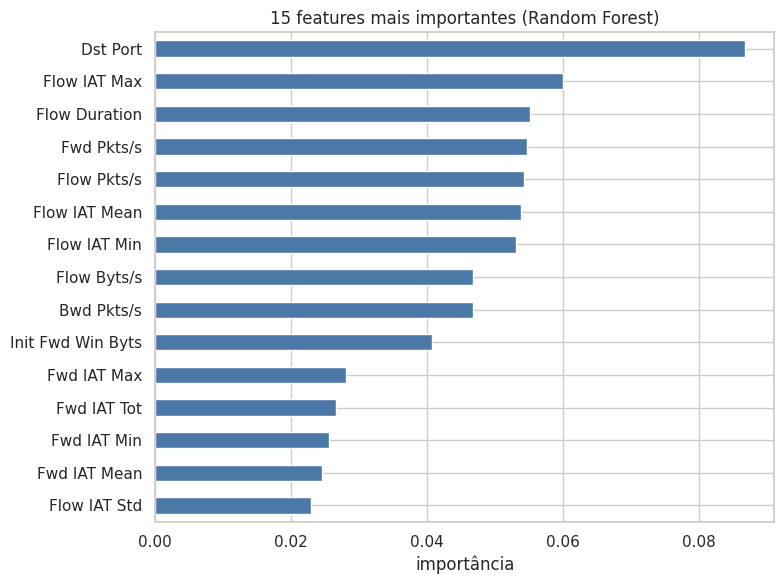

,0
Dst Port,0.086729
Flow IAT Max,0.060045
Flow Duration,0.055080
Fwd Pkts/s,0.054723
Flow Pkts/s,0.054252
Flow IAT Mean,0.053836
Flow IAT Min,0.053140
Flow Byts/s,0.046813
Bwd Pkts/s,0.046788
Init Fwd Win Byts,0.040735


In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importancias.head(15)

plt.figure(figsize=(8, 6))
top15[::-1].plot(kind='barh', color='#4C78A8')
plt.title('15 features mais importantes (Random Forest)')
plt.xlabel('importância'); plt.tight_layout(); plt.show()
top15

### Discussão
- Qual feature apareceu como a **mais importante**? Ela faz sentido do ponto de vista de redes?

A feature mais importante foi Dst Port. Isso faz sentido porque a porta de destino está relacionada ao serviço ou aplicação acessada pelo fluxo de rede. Certos tipos de tráfego e ataques podem apresentar padrões específicos de portas, fazendo com que essa informação ajude o Random Forest a separar tráfego benigno de malicioso. Porém, isso não significa que a porta seja a causa do ataque, apenas que foi uma característica útil para a classificação nesse dataset.

- Há features ligadas a **volume, duração ou quantidade de pacotes** no topo?

Sim. Entre as cinco features mais importantes apareceram:

Flow IAT Max
Flow Duration
Fwd Pkts/s
Flow Pkts/s

Flow Duration está diretamente relacionada à duração do fluxo, enquanto Fwd Pkts/s e Flow Pkts/s representam taxas de pacotes. Flow IAT Max mede o maior intervalo entre pacotes do fluxo. Portanto, boa parte das features mais importantes está relacionada ao comportamento temporal e à quantidade/taxa de pacotes.

- **Importância ≠ causalidade.** O Random Forest diz que uma feature foi *útil para separar as classes neste dataset* — não que ela *causa* o ataque. Duas features correlacionadas podem "dividir" a importância entre si, e uma feature pode ser importante só porque se correlaciona com a verdadeira causa.

A importância calculada pelo Random Forest indica o quanto uma feature foi útil para realizar as divisões das classes no conjunto de dados, mas não significa que ela seja a causa do ataque. Além disso, features correlacionadas podem compartilhar informações semelhantes e dividir sua importância no modelo.

- O que aconteceria se **removêssemos** as features do topo? (é o Exercício 3.)

O desempenho não caiu, e na verdade melhorou ligeiramente. A Balanced Accuracy foi de aproximadamente 0,506 para 0,520, e o F1 da classe ataque foi de 0,107 para 0,154. Isso sugere redundância entre features.

## 8. Modelo não supervisionado — K-Means

Agora **esquecemos os rótulos** e perguntamos: os fluxos formam **grupos naturais**? O K-Means agrupa por **distância**, então duas coisas importam:
1. Precisamos **padronizar** as features (senão `Flow Bytes/s`, na casa dos milhares, domina `SYN Flag Count`, que é ~0–2).
2. Removemos `Destination Port`: como é um inteiro, a distância trataria a porta 44720 como "muito maior" que a 80, o que **não tem sentido semântico** num modelo de distância (diferente da árvore, que a usa sem problema).

In [ ]:
X_clu = X.drop(columns=[c for c in ['Destination Port'] if c in X.columns])
scaler = StandardScaler().fit(X_clu)
X_scaled = scaler.transform(X_clu)
print('Matriz para clustering:', X_scaled.shape)

Matriz para clustering: (200001, 78)


### Escolhendo `k` — Elbow + Silhouette
Rodamos K-Means para vários `k` e olhamos a **inércia** (cotovelo) e o **silhouette score**. Para ficar rápido, calculamos numa **subamostra** de 5 mil fluxos.

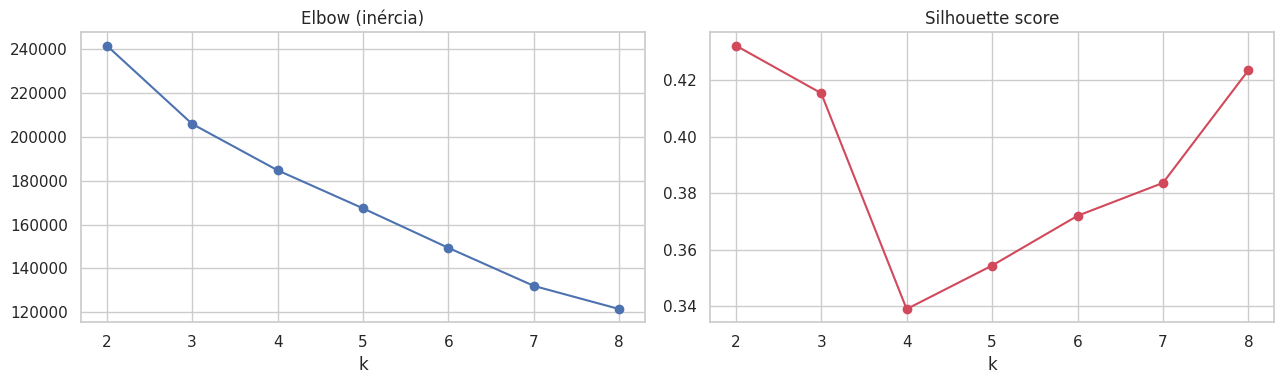

In [ ]:
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow (inércia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sils, 'o-', color='#D1495B'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

Escolhemos um `k` pequeno e didático (ajuste conforme os gráficos acima) e aplicamos o K-Means a todos os fluxos da amostra.

In [ ]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
pd.crosstab(df['cluster'], df['Label'])

Label,BENIGN,Infilteration,Label
cluster,,,
0,129111,17097,1
1,9977,1107,0
2,38254,4449,0
3,5,0,0


**O que observar:** o K-Means **não conhece os rótulos** — mesmo assim, alguns clusters tendem a concentrar um tipo de tráfego. Veja se o benigno se separou e se ataques parecidos (ex.: DoS Hulk e DDoS) caíram juntos.

## 8b. Visualização com PCA
Os dados têm dezenas de dimensões. Usamos **PCA** para projetar em 2D só para **visualizar** — comparando lado a lado os clusters do K-Means e os rótulos reais.

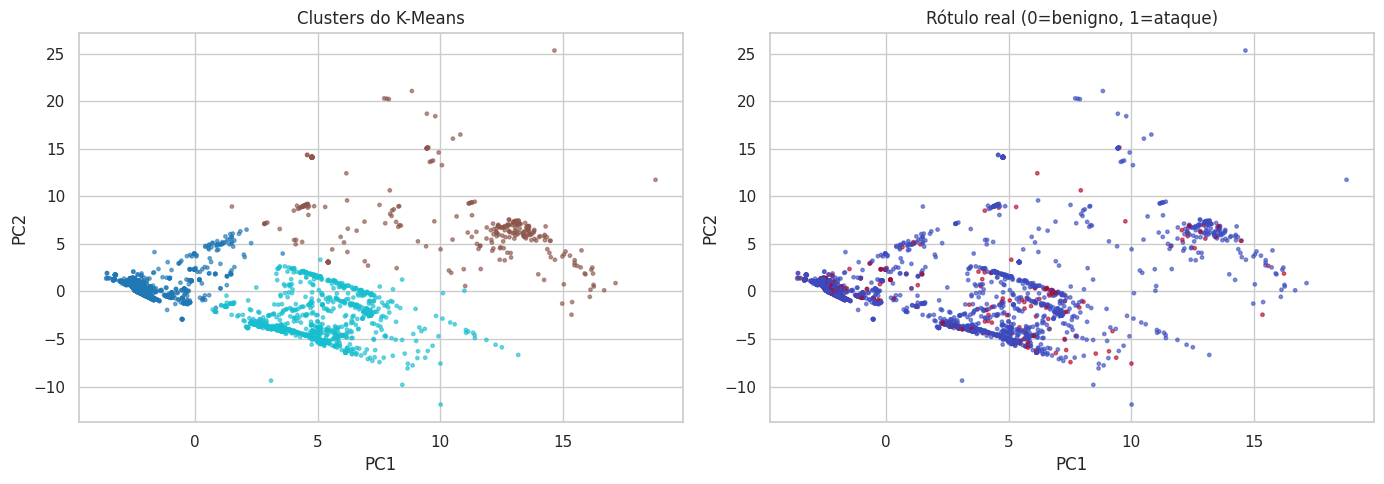

Variância explicada pelos 2 PCs: [0.234, 0.119]


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X_scaled)

vis = np.random.choice(len(Z), size=min(6000, len(Z)), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(Z[vis, 0], Z[vis, 1], c=df['cluster'].values[vis], cmap='tab10', s=6, alpha=0.6)
ax[0].set_title('Clusters do K-Means')

cores = pd.factorize(df['is_attack'].values)[0]
sc = ax[1].scatter(Z[vis, 0], Z[vis, 1], c=df['is_attack'].values[vis], cmap='coolwarm', s=6, alpha=0.6)
ax[1].set_title('Rótulo real (0=benigno, 1=ataque)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()
print('Variância explicada pelos 2 PCs:', pca.explained_variance_ratio_.round(3).tolist())

### Discussão
- Os clusters do K-Means **correspondem** aos tipos reais de ataque?

Não. Os clusters não apresentaram uma correspondência clara com os rótulos reais. Tanto o cluster 0 quanto o cluster 1 contêm grande quantidade de tráfego benigno e também amostras de Infilteration.

- O tráfego **benigno** ficou separado dos ataques?

Não. No cluster 0, aproximadamente 89,65% das amostras são benignas e 10,35% são ataques. No cluster 1, são aproximadamente 88,32% benignas e 11,68% ataques. As proporções são muito parecidas, mostrando que o K-Means não conseguiu formar um grupo claramente benigno e outro de ataques.

- Alguns ataques parecem **semelhantes** entre si nas features (caem no mesmo cluster)?

Neste recorte não é possível avaliar se diferentes tipos de ataque foram agrupados juntos, pois o conjunto analisado contém apenas o ataque Infilteration além do tráfego benigno.

- Por que o clustering **não reproduz perfeitamente** os rótulos? (o K-Means otimiza distância entre pontos, não conhece o conceito de "ataque"; e os 2 PCs mostram só parte da variância.)

Porque o K-Means é não supervisionado: ele não sabe o que é BENIGN nem Infilteration. Ele apenas tenta formar grupos de pontos próximos entre si de acordo com as features utilizadas. Portanto, a separação geométrica encontrada pelas features não precisa coincidir com os rótulos definidos no dataset.

## 9. Supervisionado vs. não supervisionado

| Abordagem     | Usa rótulos? | Objetivo          | Exemplo aqui                 |
| ------------- | ------------ | ----------------- | ---------------------------- |
| Random Forest | Sim          | Classificar       | Benigno vs. Ataque           |
| K-Means       | Não          | Encontrar grupos  | Agrupar padrões de tráfego   |

**Quando usar cada um, na prática:**
- **Supervisionado** quando você **tem rótulos confiáveis** de ataques passados e quer detectar os **conhecidos** com alta precisão.
- **Não supervisionado** quando **faltam rótulos** ou você quer descobrir **comportamento novo/anômalo** — útil para ataques que ainda não foram vistos (retomamos isso na aula 6, com detecção de anomalias).

## 10. Exercícios

**1 — EDA:** escolha **três features** e investigue como seus valores diferem entre tráfego benigno e ataques (use boxplots ou `groupby('Label').describe()`).

**2 — Random Forest:** treine de novo usando um **subconjunto diferente de features** (por exemplo, só as relacionadas a pacotes) e compare as métricas.

**3 — Feature Importance:** **remova as 5 features mais importantes** e treine de novo. O desempenho cai muito? O que isso diz sobre redundância entre features?

**4 — Clustering:** teste **outros valores de `k`** no K-Means e compare pelo **silhouette score**. Qual `k` parece melhor?

**5 — Investigação:** compare (com `pd.crosstab`) os **clusters** com os **rótulos reais** e discuta por que eles são — ou não — parecidos.

## Checklist do entregável de hoje

- [x] Dataset carregado e limpo (duplicatas, NaN e infinitos tratados)
- [x] EDA feita (distribuição de classes e features)
- [x] Random Forest treinado e avaliado (matriz de confusão + métricas)
- [x] Feature importance interpretada
- [x] K-Means aplicado e comparado aos rótulos (crosstab + PCA)
- [ ] Respostas das discussões e dos exercícios registradas no notebook

**Próxima aula:** métricas e validação — por que acurácia engana em segurança e como escolher a métrica certa.

**RESPOSTAS DOS EXERCÍCIOS DESTE NOTEBOOK**


**1 — EDA:** escolha **três features** e investigue como seus valores diferem entre tráfego benigno e ataques (use boxplots ou `groupby('Label').describe()`).


In [ ]:
features_eda = [
    'Flow Duration',
    'Tot Fwd Pkts',
    'Flow Byts/s'
]

df_eda = df[['Label'] + features_eda].copy()

for col in features_eda:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

df_eda = df_eda.replace([np.inf, -np.inf], np.nan)

for col in features_eda:
    print(f'\n===== {col} =====')
    print(
        df_eda.groupby('Label')[col]
        .describe()[['count', 'mean', '50%', 'std', 'min', 'max']]
    )


===== Flow Duration =====
                  count          mean     50%           std  min          max
Label                                                                        
BENIGN         177347.0  1.267815e+07  2469.0  3.307495e+07  0.0  119999899.0
Infilteration   22653.0  1.203933e+07  2102.0  3.208765e+07  0.0  119999839.0
Label               0.0           NaN     NaN           NaN  NaN          NaN

===== Tot Fwd Pkts =====
                  count      mean  50%        std  min      max
Label                                                          
BENIGN         177347.0  5.531326  2.0  98.621817  1.0  35275.0
Infilteration   22653.0  4.595418  2.0   9.619452  1.0    754.0
Label               0.0       NaN  NaN        NaN  NaN      NaN

===== Flow Byts/s =====
                  count           mean          50%           std  min  \
Label                                                                    
BENIGN         176716.0  304482.944368  1601.146090  4.572862e+0

Foram analisadas as features Flow Duration, Tot Fwd Pkts e Flow Byts/s. Em Flow Duration, o tráfego benigno apresentou média e mediana ligeiramente superiores às observadas em Infilteration, mas os valores são relativamente próximos. Em Tot Fwd Pkts, o tráfego benigno apresentou maior média de pacotes encaminhados, embora ambas as classes tenham mediana igual a 2, indicando considerável sobreposição entre as distribuições. Já em Flow Byts/s, os ataques apresentaram média superior ao tráfego benigno, enquanto as medianas foram muito semelhantes. Isso mostra que nenhuma dessas features, isoladamente, separa perfeitamente as classes, e que a combinação de múltiplas características tende a ser mais útil para distinguir tráfego benigno de ataques.

**2 — Random Forest:** treine de novo usando um **subconjunto diferente de features** (por exemplo, só as relacionadas a pacotes) e compare as métricas.

In [ ]:
features_pacotes = ['Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts',
                    'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
                    'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std',
                    'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Size Avg']

features_pacotes = [c for c in features_pacotes if c in X.columns]
X_pacotes = X[features_pacotes]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pacotes, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED
)

rf_pacotes = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                    n_jobs=-1, random_state=RANDOM_SEED)

rf_pacotes.fit(X_train_p, y_train_p)
y_pred_p = rf_pacotes.predict(X_test_p)

print(classification_report(y_test_p, y_pred_p))
print('Balanced Accuracy:', balanced_accuracy_score(y_test_p, y_pred_p))
print('F1:', f1_score(y_test_p, y_pred_p))

print('\n=== Comparação ===')
print('Original - Balanced Accuracy:', balanced_accuracy_score(y_test, y_pred))
print('Original - F1:', f1_score(y_test, y_pred))
print('Pacotes  - Balanced Accuracy:', balanced_accuracy_score(y_test_p, y_pred_p))
print('Pacotes  - F1:', f1_score(y_test_p, y_pred_p))

              precision    recall  f1-score   support

           0       0.90      0.67      0.76     53205
           1       0.13      0.40      0.20      6796

    accuracy                           0.64     60001
   macro avg       0.51      0.53      0.48     60001
weighted avg       0.81      0.64      0.70     60001

Balanced Accuracy: 0.5319170289781122
F1: 0.1982365907421014

=== Comparação ===
Original - Balanced Accuracy: 0.5058017026771139
Original - F1: 0.10722809410160246
Pacotes  - Balanced Accuracy: 0.5319170289781122
Pacotes  - F1: 0.1982365907421014


Ao treinar o Random Forest apenas com features relacionadas a pacotes, houve uma pequena melhora no desempenho em relação ao modelo original. A Balanced Accuracy aumentou de aproximadamente 0,506 para 0,532 e o F1-score da classe de ataque subiu de 0,107 para 0,198. O novo modelo apresentou recall de 0,40 para ataques, indicando maior capacidade de detectá-los, porém com precisão de apenas 0,13, o que sugere aumento de falsos positivos. Assim, as features relacionadas a pacotes parecem conter informação relevante para a identificação de ataques, embora ainda não sejam suficientes para uma classificação robusta isoladamente.

**3 — Feature Importance:** **remova as 5 features mais importantes** e treine de novo. O desempenho cai muito? O que isso diz sobre redundância entre features?

In [ ]:
top5 = importancias.head(5).index.tolist()
print('5 features mais importantes:', top5)

X_sem_top5 = X.drop(columns=top5)

X_train_s5, X_test_s5, y_train_s5, y_test_s5 = train_test_split(
    X_sem_top5, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED
)

rf_sem_top5 = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED
)

rf_sem_top5.fit(X_train_s5, y_train_s5)
y_pred_s5 = rf_sem_top5.predict(X_test_s5)

print('\n=== SEM AS 5 FEATURES MAIS IMPORTANTES ===')
print(classification_report(y_test_s5, y_pred_s5))
print('Balanced Accuracy:', balanced_accuracy_score(y_test_s5, y_pred_s5))
print('F1:', f1_score(y_test_s5, y_pred_s5))

print('\n=== COMPARAÇÃO ===')
print('Original - Balanced Accuracy:', balanced_accuracy_score(y_test, y_pred))
print('Original - F1:', f1_score(y_test, y_pred))
print('Sem top 5 - Balanced Accuracy:', balanced_accuracy_score(y_test_s5, y_pred_s5))
print('Sem top 5 - F1:', f1_score(y_test_s5, y_pred_s5))

5 features mais importantes: ['Dst Port', 'Flow IAT Max', 'Flow Duration', 'Fwd Pkts/s', 'Flow Pkts/s']

=== SEM AS 5 FEATURES MAIS IMPORTANTES ===
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     53205
           1       0.14      0.16      0.15      6796

    accuracy                           0.79     60001
   macro avg       0.52      0.52      0.52     60001
weighted avg       0.81      0.79      0.80     60001

Balanced Accuracy: 0.5198369298424216
F1: 0.15357118306179968

=== COMPARAÇÃO ===
Original - Balanced Accuracy: 0.5058017026771139
Original - F1: 0.10722809410160246
Sem top 5 - Balanced Accuracy: 0.5198369298424216
Sem top 5 - F1: 0.15357118306179968


As cinco features mais importantes identificadas foram Dst Port, Flow IAT Max, Flow Duration, Fwd Pkts/s e Flow Pkts/s. Após removê-las e treinar novamente o Random Forest, o desempenho não apresentou queda. Pelo contrário, a Balanced Accuracy aumentou de aproximadamente 0,506 para 0,520 e o F1-score da classe de ataque passou de 0,107 para 0,154. Isso indica que existe redundância entre as features do dataset, pois outras variáveis foram capazes de fornecer informações semelhantes às removidas. A pequena melhora também sugere que algumas das features mais importantes do modelo original podem ter introduzido ruído ou levado o modelo a depender excessivamente de determinados padrões.

**4 — Clustering:** teste **outros valores de `k`** no K-Means e compare pelo **silhouette score**. Qual `k` parece melhor?

   k  silhouette        inercia
0  2    0.432230  241617.103724
1  3    0.415370  205880.408105
2  4    0.339057  184738.862581
3  5    0.354435  167387.432097
4  6    0.372027  149363.480898
5  7    0.383648  132029.126398
6  8    0.423474  121470.474967

Melhor k: 2
Melhor silhouette: 0.4322298399537656


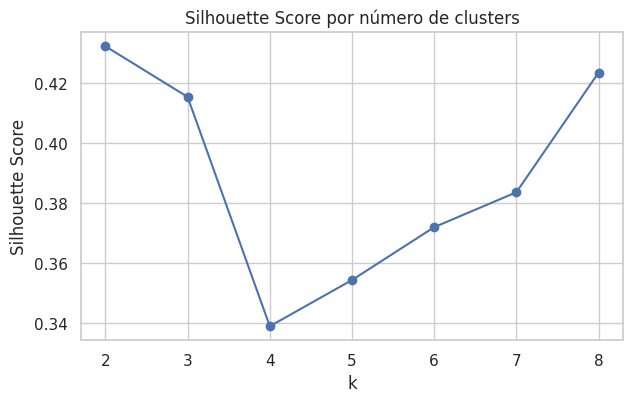

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

np.random.seed(RANDOM_SEED)
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

resultados_k = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
    labels_k = km.fit_predict(X_sub)
    sil = silhouette_score(X_sub, labels_k)
    resultados_k.append([k, sil, km.inertia_])

resultados_k = pd.DataFrame(resultados_k, columns=['k', 'silhouette', 'inercia'])

print(resultados_k)

melhor = resultados_k.loc[resultados_k['silhouette'].idxmax()]
print('\nMelhor k:', int(melhor['k']))
print('Melhor silhouette:', melhor['silhouette'])

plt.figure(figsize=(7,4))
plt.plot(resultados_k['k'], resultados_k['silhouette'], marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por número de clusters')
plt.xticks(resultados_k['k'])
plt.grid(True)
plt.show()

Foram testados valores de k entre 2 e 8 no K-Means. O maior silhouette score foi obtido com k = 2, com valor aproximado de 0,432, indicando que, entre os valores testados, essa configuração produziu os clusters mais coesos e melhor separados. O segundo melhor resultado ocorreu com k = 8, com silhouette de aproximadamente 0,423. Apesar disso, pelo critério do silhouette score, k = 2 é a melhor escolha.

**5 — Investigação:** compare (com `pd.crosstab`) os **clusters** com os **rótulos reais** e discuta por que eles são — ou não — parecidos.

In [ ]:
K = 2

kmeans_final = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

tabela = pd.crosstab(df['cluster'], df['Label'])
print('=== CONTAGEM ===')
print(tabela)

tabela_pct = pd.crosstab(df['cluster'], df['Label'], normalize='index') * 100
print('\n=== PERCENTUAL POR CLUSTER ===')
print(tabela_pct.round(2))

=== CONTAGEM ===
Label    BENIGN  Infilteration  Label
cluster                              
0         47242           5453      0
1        130105          17200      1

=== PERCENTUAL POR CLUSTER ===
Label    BENIGN  Infilteration  Label
cluster                              
0         89.65          10.35    0.0
1         88.32          11.68    0.0


Ao comparar os clusters gerados pelo K-Means com os rótulos reais, observou-se que eles não correspondem diretamente às classes BENIGN e Infilteration. O cluster 0 apresentou aproximadamente 89,65% de tráfego benigno e 10,35% de ataques, enquanto o cluster 1 apresentou cerca de 88,32% de tráfego benigno e 11,68% de ataques. Portanto, ambos os clusters possuem proporções muito semelhantes das duas classes. Isso ocorre porque o K-Means é um algoritmo não supervisionado e não utiliza os rótulos reais durante o agrupamento. Ele forma os clusters apenas com base na similaridade entre as features. Assim, os padrões encontrados nos dados não parecem separar naturalmente tráfego benigno e ataques de infiltração.

**RESPOSTAS DOS EXERCÍCIOS DO TXT EXTERNO**


**1. Valores infinitos. O CIC-IDS2017 traz valores infinitos em colunas como Flow Bytes/s. Por que eles aparecem (o que acontece quando se divide por um tempo quase zero)? E por que não dá para simplesmente deixá-los na base antes de treinar o modelo?**

Valores infinitos podem aparecer em features como Flow Bytes/s quando a quantidade de bytes é dividida por uma duração de fluxo igual ou muito próxima de zero. Nesse caso, o resultado da divisão cresce muito ou pode se tornar infinito. Esses valores não devem ser deixados diretamente na base porque muitos algoritmos de aprendizado de máquina não conseguem processar inf ou -inf, além de esses valores distorcerem estatísticas, normalização e cálculos de distância. Por isso, é necessário tratá-los antes do treinamento, por exemplo substituindo-os por NaN e depois decidindo como lidar com esses valores.

**2. Duplicatas e ausentes. Encontramos linhas duplicadas e valores ausentes (NaN). O que poderia dar errado no modelo se deixássemos muitas duplicatas de um mesmo ataque na base? E por que descartar NaN é uma decisão que precisa ser pensada, e não automática?**

Se houver muitas linhas duplicadas de um mesmo ataque, o modelo pode dar importância excessiva àquele padrão específico, como se ele fosse mais frequente ou representativo do que realmente é. Isso pode favorecer overfitting e produzir métricas artificialmente boas, principalmente se duplicatas semelhantes aparecerem tanto no treino quanto no teste. Já os valores NaN não devem ser simplesmente descartados de forma automática, porque a ausência de um dado pode ter significado e a remoção de muitas linhas pode alterar a distribuição da base. Dependendo do caso, pode ser melhor remover a linha, remover a feature ou realizar algum tipo de imputação.

**3. Desbalanceamento (EDA). Ao contar os rótulos, a imensa maioria é BENIGN. Como esse desbalanceamento pode enganar alguém que olha só a acurácia do modelo? Qual gráfico ou número da EDA ajuda a perceber isso antes de treinar?**

Quando a maioria das amostras pertence à classe BENIGN, a acurácia pode dar uma impressão enganosa de bom desempenho. Por exemplo, um modelo que classificasse quase tudo como benigno poderia obter uma acurácia alta simplesmente porque essa é a classe dominante, mesmo detectando poucos ataques. Antes do treinamento, esse problema pode ser percebido pela contagem dos rótulos, por um gráfico de barras da distribuição das classes ou pela proporção percentual de cada classe. Depois do treinamento, métricas como recall, F1-score e balanced accuracy são mais úteis para avaliar a capacidade de detectar ataques.

**4. Normalização. Duas features da base são Flow Bytes/s (na casa dos milhares) e SYN Flag Count (de 0 a 2). Com suas palavras: por que, sem padronizar, o K-Means daria mais "peso" a uma delas? E por que o Random Forest não sofre com esse problema?**

O K-Means agrupa os dados utilizando distâncias entre os pontos. Se uma feature, como Flow Bytes/s, possui valores na casa dos milhares e outra, como SYN Flag Count, varia apenas entre 0 e 2, a primeira terá uma influência muito maior no cálculo da distância simplesmente por causa da sua escala. A padronização coloca as features em escalas comparáveis, evitando esse efeito. O Random Forest não sofre da mesma forma porque suas decisões são feitas por divisões individuais em cada feature, como feature <= valor, e não pelo cálculo de distância entre variáveis de escalas diferentes.

**5. Comparar uma feature. Escolha uma feature e compare seus valores entre o tráfego benigno e um tipo de ataque (com describe() ou um boxplot). O que a diferença — ou a falta dela — sugere sobre a utilidade dessa feature para separar as classes?**

Foi analisada a feature Tot Fwd Pkts. No tráfego BENIGN, a média foi de aproximadamente 5,53 pacotes, enquanto no tráfego Infilteration foi de aproximadamente 4,60 pacotes. Apesar dessa diferença na média, ambas as classes apresentaram mediana igual a 2 pacotes. Isso sugere que existe bastante sobreposição entre as distribuições e que essa feature, isoladamente, provavelmente não é suficiente para separar bem tráfego benigno de ataques. Ela pode ser útil quando combinada com outras características do fluxo.